# Points of Interest from OSM
### This notebook contains a minimal example of using accessX to retrieve, inspect, and save POIs from OpenStreetMap for Amsterdam, Athens, and Milan.

The focus is the `accessx.poi` module: explicit OSM tags, optional custom POI groups, robust retries, progress bars, query reports, clean output columns, and saved GeoJSON outputs.

In [1]:
import json
from pathlib import Path

import accessx as acx
import geopandas as gpd
import matplotlib.pyplot as plt
import osmnx as ox
import pandas as pd

### Load Areas of Interest

In [2]:
epsg_ams = 28992
epsg_ath = 2100
epsg_mil = 32632

data_path = Path("../data/case_studies/pois")
area_path = data_path / "area"
pois_path = data_path / "pois"
report_path = data_path / "reports"

for folder in [data_path, area_path, pois_path, report_path]:
    folder.mkdir(parents=True, exist_ok=True)

gdf_ams = ox.geocode_to_gdf("Amsterdam, Netherlands")
gdf_ath = ox.geocode_to_gdf("Municipality of Athens, Greece")
gdf_mil = ox.geocode_to_gdf("Milan, Italy")

# Uncomment to read AOIs from disk instead of geocoding.
# gdf_ams = acx.read_gdf(area_path / "aoi_amsterdam.geojson")
# gdf_ath = acx.read_gdf(area_path / "aoi_athens.geojson")
# gdf_mil = acx.read_gdf(area_path / "aoi_milan.geojson")

cities = [
    {"name": "amsterdam", "label": "Amsterdam", "aoi": gdf_ams, "epsg": epsg_ams},
    {"name": "athens", "label": "Athens", "aoi": gdf_ath, "epsg": epsg_ath},
    {"name": "milan", "label": "Milan", "aoi": gdf_mil, "epsg": epsg_mil},
]

for city in cities:
    acx.save_gdf(city["aoi"], area_path / f"aoi_{city['name']}.geojson")

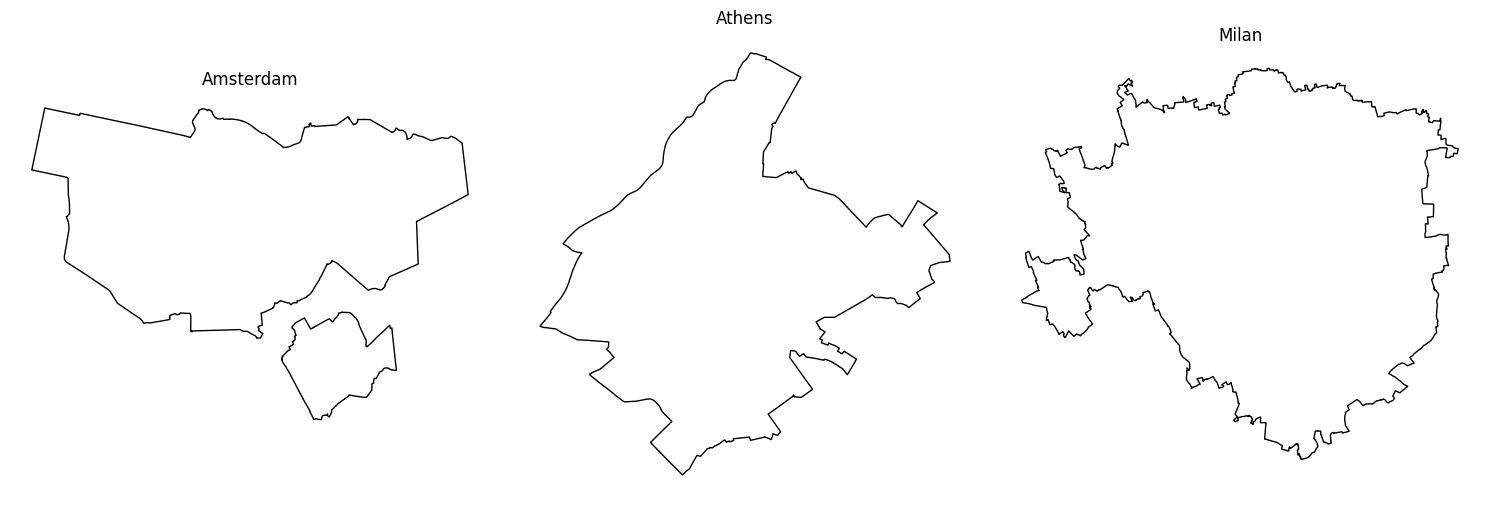

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, city in zip(axes, cities):
    city["aoi"].plot(ax=ax, facecolor="none", edgecolor="black")
    ax.set_title(city["label"])
    ax.axis("off")

plt.tight_layout()
plt.show()

### Define Custom POI Groups

Use `poi_groups` when you want your own accessibility or walkability categories. The top-level keys become the output `category`. Inside each group, use explicit OSM tags:

- `True` selects the whole OSM key, such as `{"healthcare": True}` for all `healthcare=*` features.
- A string selects one OSM value, such as `{"amenity": "pharmacy"}`.
- A list selects several OSM values, such as `{"leisure": ["park", "playground"]}`.

The output keeps both levels: `category` is your custom group, while `osm_key` and `osm_value` preserve the original OSM tags. `subcategory` is the matched OSM value for convenience.

In [ ]:
poi_groups = {
    "healthcare": {
        "amenity": ["pharmacy", "clinic", "doctors", "dentist", "hospital"],
        "healthcare": True,
    },
    "education": {
        "amenity": ["kindergarten", "childcare", "school", "college", "university", "library"],
    },
    "daily_needs": {
        "shop": ["supermarket", "convenience", "greengrocer", "bakery", "butcher", "chemist"],
        "amenity": ["marketplace", "post_office", "bank", "atm"],
    },
    "open_space_and_play": {
        "leisure": ["park", "playground", "garden", "dog_park", "recreation_ground"],
    },
    "sports_and_activity": {
        "leisure": ["sports_centre", "fitness_centre", "fitness_station", "swimming_pool", "pitch", "track"],
    },
    "public_transport": {
        "highway": ["bus_stop"],
        "railway": ["station", "halt", "tram_stop", "subway_entrance"],
        "public_transport": ["platform", "stop_position", "station"],
    },
    "civic_and_culture": {
        "amenity": ["community_centre", "townhall", "police", "place_of_worship"],
        "tourism": ["museum", "gallery", "information"],
    },
}


{'healthcare': {'amenity': ['pharmacy',
   'clinic',
   'doctors',
   'dentist',
   'hospital'],
  'healthcare': True},
 'education': {'amenity': ['kindergarten',
   'childcare',
   'school',
   'college',
   'university',
   'library']},
 'daily_needs': {'shop': ['supermarket',
   'convenience',
   'greengrocer',
   'bakery',
   'butcher',
   'chemist'],
  'amenity': ['marketplace', 'post_office', 'bank', 'atm']},
 'open_space_and_play': {'leisure': ['park',
   'playground',
   'garden',
   'dog_park',
   'recreation_ground']},
 'sports_and_activity': {'leisure': ['sports_centre',
   'fitness_centre',
   'fitness_station',
   'swimming_pool',
   'pitch',
   'track']},
 'public_transport': {'highway': ['bus_stop'],
  'railway': ['station', 'halt', 'tram_stop', 'subway_entrance'],
  'public_transport': ['platform', 'stop_position', 'station']},
 'civic_and_culture': {'amenity': ['community_centre',
   'townhall',
   'police',
   'place_of_worship'],
  'tourism': ['museum', 'gallery', 'i

### Retrieve POIs With Retries, Progress, and Reports

The important completeness behavior is here:

- `max_retries` controls how many times each OSM query is retried after transient OSM/Overpass failures.
- `show_progress=True` displays progress while each OSM query is processed.
- accessX uses built-in retry delays and short pauses between OSM queries.
- Failed OSM queries raise `POIQueryError` after retries, so incomplete downloads do not pass unnoticed.
- `return_report=True` returns a per-city report with retrieved counts, empty queries, and failed query details.

In [6]:
def collect_city_pois(city):
    pois, report = acx.get_pois_osm(
        city["aoi"],
        poi_groups=poi_groups,
        max_retries=4,
        show_progress=True,
        return_report=True,
        columns=["amenity", "leisure", "shop", "highway", "railway", "public_transport", "healthcare", "tourism"],
    )

    acx.save_gdf(pois, pois_path / f"pois_{city['name']}.geojson")
    (report_path / f"poi_report_{city['name']}.json").write_text(
        json.dumps(report, indent=2),
        encoding="utf-8",
    )
    return pois, report


pois_by_city = {}
reports_by_city = {}

for city in cities:
    pois_by_city[city["name"]], reports_by_city[city["name"]] = collect_city_pois(city)

# Uncomment to read saved POIs from disk instead of querying OSM again.
# pois_by_city = {
#     city["name"]: acx.read_gdf(pois_path / f"pois_{city['name']}.geojson")
#     for city in cities
# }
# reports_by_city = {
#     city["name"]: json.loads((report_path / f"poi_report_{city['name']}.json").read_text())
#     for city in cities
# }

Retrieving POIs:   0%|          | 0/12 [00:00<?, ?query/s]

Retrieving POIs:   0%|          | 0/12 [00:00<?, ?query/s]

Retrieving POIs:   0%|          | 0/12 [00:00<?, ?query/s]

### Summarize POIs by Custom Category and OSM Value

In [10]:
summary = []
for city in cities:
    pois = pois_by_city[city["name"]]
    counts = (
        pois.groupby(["category", "osm_key", "osm_value"], dropna=False)
        .size()
        .rename("pois")
        .reset_index()
    )
    counts.insert(0, "city", city["label"])
    summary.append(counts)

poi_summary = pd.concat(summary, ignore_index=True)
poi_summary

,city,category,osm_key,osm_value,pois
0,Amsterdam,civic_and_culture,amenity,community_centre,127
1,Amsterdam,civic_and_culture,amenity,place_of_worship,184
2,Amsterdam,civic_and_culture,amenity,police,20
3,Amsterdam,civic_and_culture,amenity,townhall,9
4,Amsterdam,civic_and_culture,tourism,gallery,80
...,...,...,...,...,...
195,Milan,sports_and_activity,leisure,fitness_station,64
196,Milan,sports_and_activity,leisure,pitch,1504
197,Milan,sports_and_activity,leisure,sports_centre,182
198,Milan,sports_and_activity,leisure,swimming_pool,112


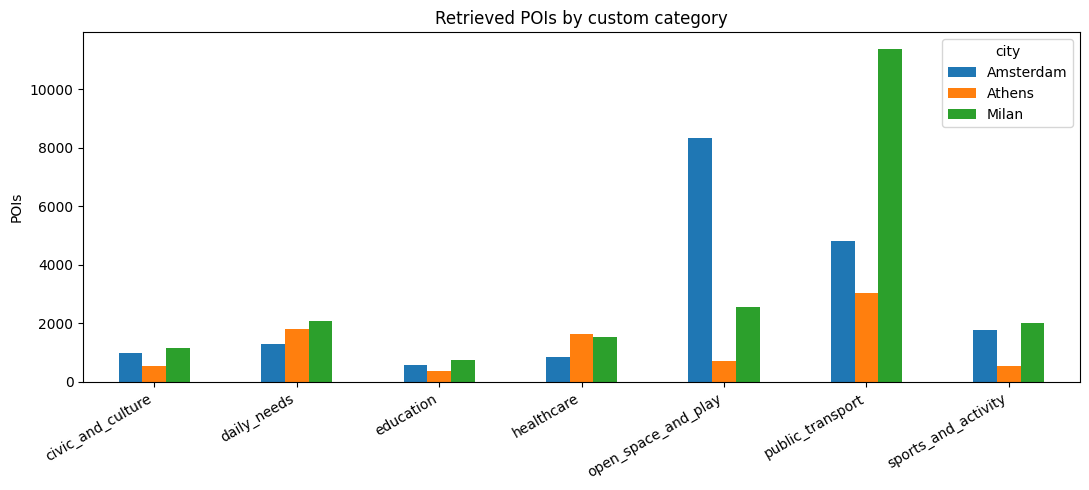

In [11]:
fig, ax = plt.subplots(figsize=(11, 5))

category_summary = (
    poi_summary.groupby(["city", "category"])["pois"]
    .sum()
    .reset_index()
)
pivot = category_summary.pivot(index="category", columns="city", values="pois").fillna(0)
pivot.plot(kind="bar", ax=ax)
ax.set_xlabel("")
ax.set_ylabel("POIs")
ax.set_title("Retrieved POIs by custom category")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

### Map Retrieved POIs

OSM returns both point and polygon features. For display, polygons are represented with `representative_point()` so every POI can be shown as a symbol.

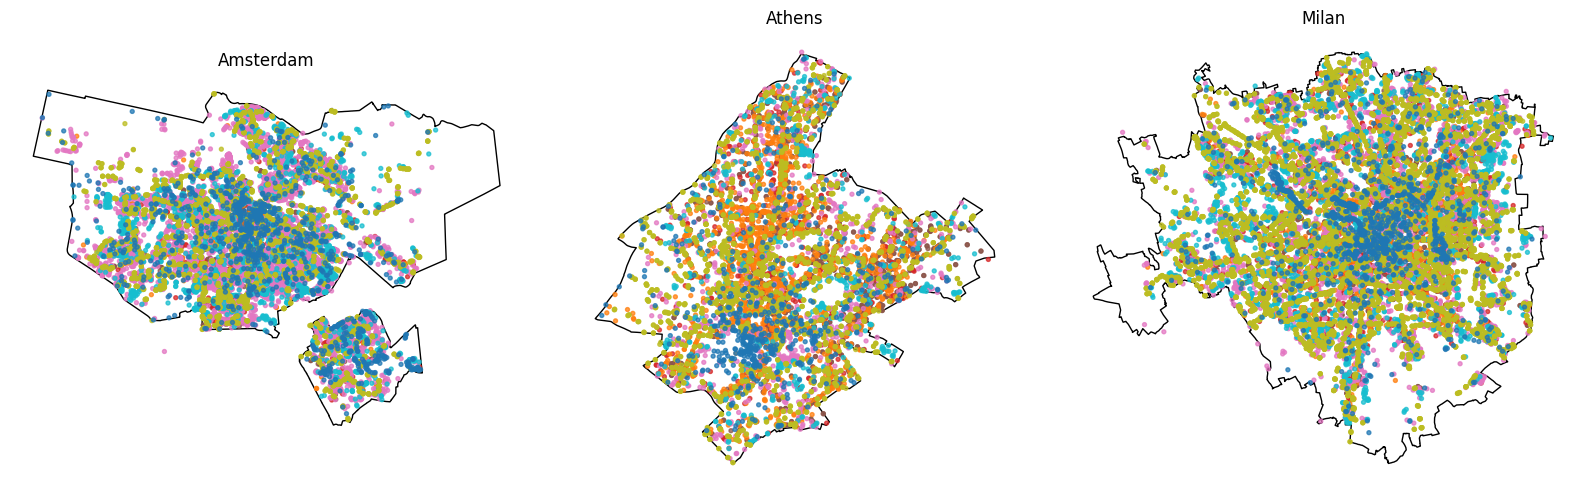

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, city in zip(axes, cities):
    aoi = city["aoi"].to_crs(city["epsg"])
    pois = pois_by_city[city["name"]].to_crs(city["epsg"])
    poi_points = pois.copy()
    poi_points["geometry"] = poi_points.geometry.apply(
        lambda geom: geom if geom.geom_type == "Point" else geom.representative_point()
    )

    aoi.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=1)
    poi_points.plot(ax=ax, column="category", markersize=8, legend=False, alpha=0.75)
    ax.set_title(city["label"])
    ax.axis("off")

plt.tight_layout()
plt.show()

### Direct OSM Tag Mode

Use `osm_tags` when you do not need custom categories and want the output `category` to be the OSM key itself.

In [ ]:
ams_direct_osm, ams_direct_osm_report = acx.get_pois_osm(
    gdf_ams,
    osm_tags={
        "amenity": ["pharmacy", "clinic"],
        "leisure": ["park", "playground"],
        "healthcare": True,
    },
    max_retries=4,
    show_progress=True,
    return_report=True,
    columns="minimal",
)

ams_direct_osm[["category", "subcategory", "osm_key", "osm_value"]].head()

### Optional: Handle Query Errors

If Overpass still fails after the configured retries, `get_pois_osm` raises `POIQueryError` with the OSM queries that failed. Increase `max_retries` for a slower, more persistent download.

In [ ]:
# try:
#     pois_debug, report_debug = acx.get_pois_osm(
#         gdf_ams,
#         poi_groups=poi_groups,
#         max_retries=1,
#         show_progress=True,
#         return_report=True,
#     )
# except acx.POIQueryError as error:
#     print(error)